# DistilBERT Sentiment Inference: Confidence Is Not Understanding

## Goal

Use a fine-tuned BERT-family model to classify sentiment, inspect both class
probabilities, and probe where a confident answer can still be incomplete or
misleading.

This is an inference demonstration, not model training. It replaces an earlier
one-cell prototype with a pinned model revision, explicit checks, and examples
that include negation, mixed sentiment, and a backhanded compliment.

## Setup

Install `requirements-course-demos.txt` and run the notebook from the repository
root. The first run downloads the pinned
[`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english)
checkpoint into the ignored `data/` directory. No model weights are committed.

DistilBERT is a smaller BERT-family model fine-tuned on SST-2 movie-review
sentiment. Its output labels and confidence scores are specific to that task;
they are not general measures of tone, intent, safety, or truth.

In [1]:
from pathlib import Path
import os
import random

CACHE_DIR = Path("data/huggingface").resolve()
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["HF_HOME"] = str(CACHE_DIR)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from huggingface_hub.utils import logging as hf_logging
from transformers import pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
hf_logging.set_verbosity_error()

MODEL_ID = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
MODEL_REVISION = "714eb0fa89d2f80546fda750413ed43d93601a13"

print(f"torch={torch.__version__}; transformers={transformers.__version__}")
print(f"model={MODEL_ID}@{MODEL_REVISION[:8]}")

torch=2.14.0; transformers=5.17.0
model=distilbert/distilbert-base-uncased-finetuned-sst-2-english@714eb0fa


## Steps

### 1. Load the pinned classifier

In [2]:
classifier = pipeline(
    "text-classification",
    model=MODEL_ID,
    revision=MODEL_REVISION,
    device=-1,
)
print("Classifier loaded on CPU.")

Classifier loaded on CPU.


### 2. Score straightforward and difficult examples

The first two examples have clear polarity. The others test negation, mixed
sentiment, and context that a binary movie-review classifier cannot fully
represent.

In [3]:
examples = pd.DataFrame(
    [
        ("clear positive", "The tutorial was clear, practical, and useful."),
        ("clear negative", "The tutorial was confusing, incomplete, and frustrating."),
        ("negation", "The tutorial was not bad at all."),
        ("mixed", "The tutorial was predictable, but I still enjoyed it."),
        ("ambiguous", "You look great for your age."),
    ],
    columns=["case", "text"],
)

raw_scores = classifier(
    examples["text"].tolist(),
    top_k=None,
    truncation=True,
)

scored_rows = []
for example, scores in zip(examples.to_dict("records"), raw_scores):
    by_label = {item["label"].upper(): float(item["score"]) for item in scores}
    scored_rows.append(
        {
            **example,
            "negative_probability": by_label["NEGATIVE"],
            "positive_probability": by_label["POSITIVE"],
            "prediction": max(by_label, key=by_label.get),
            "confidence": max(by_label.values()),
        }
    )

results = pd.DataFrame(scored_rows)
results.style.format(
    {
        "negative_probability": "{:.3f}",
        "positive_probability": "{:.3f}",
        "confidence": "{:.3f}",
    }
)

,case,text,negative_probability,positive_probability,prediction,confidence
0,clear positive,"The tutorial was clear, practical, and useful.",0.000,1.000,POSITIVE,1.000
1,clear negative,"The tutorial was confusing, incomplete, and frustrating.",1.000,0.000,NEGATIVE,1.000
2,negation,The tutorial was not bad at all.,0.003,0.997,POSITIVE,0.997
3,mixed,"The tutorial was predictable, but I still enjoyed it.",0.000,1.000,POSITIVE,1.000
4,ambiguous,You look great for your age.,0.000,1.000,POSITIVE,1.000


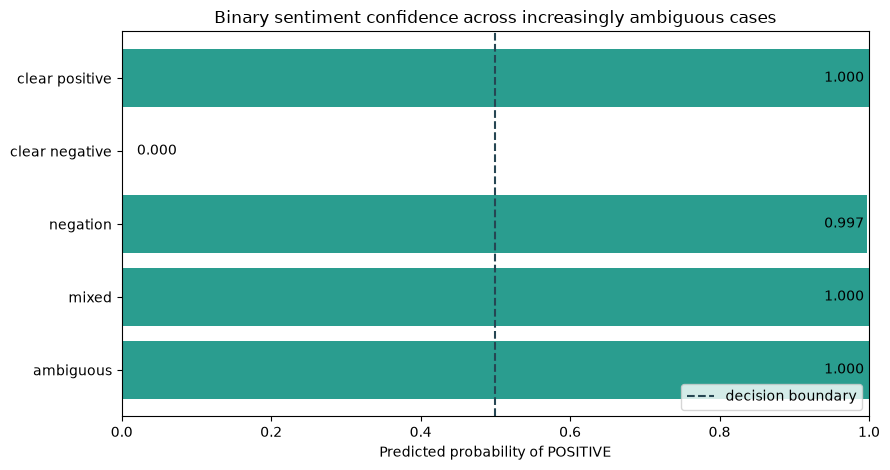

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = np.where(results["positive_probability"] >= 0.5, "#2a9d8f", "#e76f51")
bars = ax.barh(results["case"], results["positive_probability"], color=colors)
ax.axvline(0.5, color="#264653", linestyle="--", linewidth=1.5, label="decision boundary")
ax.set(xlim=(0, 1), xlabel="Predicted probability of POSITIVE", ylabel="")
ax.set_title("Binary sentiment confidence across increasingly ambiguous cases")
ax.invert_yaxis()
ax.legend(loc="lower right")
for bar, value in zip(bars, results["positive_probability"]):
    ax.text(min(value + 0.02, 0.94), bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

### 3. Inspect the tokenizer

DistilBERT does not read words directly. Its tokenizer breaks text into
subword pieces before the classifier sees it.

In [5]:
token_rows = []
for row in examples.itertuples(index=False):
    tokens = classifier.tokenizer.tokenize(row.text)
    token_rows.append({"case": row.case, "token_count": len(tokens), "wordpieces": " | ".join(tokens)})

pd.DataFrame(token_rows)

,case,token_count,wordpieces
0,clear positive,11,"the | tutor | ##ial | was | clear | , | practi..."
1,clear negative,11,"the | tutor | ##ial | was | confusing | , | in..."
2,negation,9,the | tutor | ##ial | was | not | bad | at | a...
3,mixed,12,"the | tutor | ##ial | was | predictable | , | ..."
4,ambiguous,7,you | look | great | for | your | age | .


## Checks

In [6]:
probability_sums = results["negative_probability"] + results["positive_probability"]

assert np.isfinite(results[["negative_probability", "positive_probability"]].to_numpy()).all()
assert results[["negative_probability", "positive_probability"]].to_numpy().min() >= 0
assert results[["negative_probability", "positive_probability"]].to_numpy().max() <= 1
assert np.allclose(probability_sums, 1.0, atol=1e-5)
assert results.loc[results["case"] == "clear positive", "positive_probability"].item() > 0.90
assert results.loc[results["case"] == "clear negative", "negative_probability"].item() > 0.90

print("Checks passed: finite probabilities, normalized class scores, and sensible anchor cases.")

Checks passed: finite probabilities, normalized class scores, and sensible anchor cases.


## Next Steps

- Compare the model with a human-labeled evaluation set instead of a few probes.
- Measure calibration; a score near 1.0 does not guarantee correctness.
- Test dialect, demographic references, sarcasm, and domain shift for systematic errors.
- Replace binary sentiment with an intent- or emotion-specific model when the task requires richer labels.

The main lesson is simple: a convenient pipeline can make inference easy, but
confidence is a property of the model's output—not proof that it understood the
sentence or that the label is appropriate.